# Полный цикл обработки COMTRADE-файлов для локализации КЗ

## Описание

Этот notebook выполняет полный цикл обработки осциллограмм КЗ:
1. Парсинг .cfg и .dat файлов COMTRADE
2. Фильтрация Баттерворта (удаление DC)
3. Детекция момента КЗ
4. Оконирование сигнала
5. Вычисление симметричных составляющих (Фортескю)
6. Классификация вида КЗ
7. Нормализация в p.u.
8. Формирование итогового тензора

**После каждого этапа строятся графики с разметкой величин для проверки корректности.**

In [ ]:
!pip install numpy pandas matplotlib scipy comtrade

In [ ]:
# =============================================================================
# Импорт библиотек
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import struct
import re
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

from comtrade import Comtrade

# Настройка графиков
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['grid.alpha'] = 0.3

print("✓ Библиотеки загружены")


## Раздел 1: Парсинг COMTRADE-файлов

### 1.1 Структура COMTRADE

COMTRADE (IEEE Std C37.111) состоит из двух файлов:
- **.cfg** — конфигурация (метаданные)
- **.dat** — данные (осциллограмма)

In [17]:

import os
import glob
from pathlib import Path

# Путь к папке с данными
DATA_FOLDER = 'data'  # Измените на ваш путь, например: '/content/data' или 'C:/Data'

def find_comtrade_files(folder_path):
    """Поиск всех пар .cfg и .dat файлов в папке"""
    cfg_files = glob.glob(os.path.join(folder_path, '*.cfg'))
    comtrade_pairs = []
    
    for cfg_path in cfg_files:
        base_name = cfg_path[:-4]  # убираем .cfg
        dat_path = base_name + '.dat'
        
        if os.path.exists(dat_path):
            comtrade_pairs.append({
                'cfg': cfg_path,
                'dat': dat_path,
                'name': os.path.basename(base_name)
            })
        else:
            print(f"⚠️  Предупреждение: для {cfg_path} не найден .dat файл")
    
    return comtrade_pairs

# Поиск файлов
comtrade_files = find_comtrade_files(DATA_FOLDER)

print(f"✓ Найдено {len(comtrade_files)} пар COMTRADE-файлов:")
for i, pair in enumerate(comtrade_files, 1):
    cfg_path = pair['cfg']
    print(f"  {i}. {pair['name']}")
    print(f"     cfg: {cfg_path}")
    print(f"     dat: {pair['dat']}")

✓ Найдено 1 пар COMTRADE-файлов:
  1. 3.1.1(K3, 1A)
     cfg: data\3.1.1(K3, 1A).cfg
     dat: data\3.1.1(K3, 1A).dat


In [18]:
def inspect_channels(rec):
    """Выводит список всех обнаруженных фазных каналов с их номерами из CFG."""
    print(f"{'№':<5} | {'Название канала':<20} | {'Тип':<5} | {'Сторона':<10}")
    print("-" * 50)
    
    found_info = {}
    for i, name in enumerate(rec.analog_channel_ids):
        n_up = name.upper()
        
        # Фильтр фазы и типа
        phase = next((p for p in ['A', 'B', 'C', 'А', 'В', 'С'] if p in n_up), None)
        is_u = any(x in n_up for x in ['U', 'У', 'V'])
        is_i = any(x in n_up for x in ['I', 'И'])
        
        if phase and (is_u or is_i):
            ch_num = i + 1 # Номер как в CFG
            side = "Secondary" if "SEC" in n_up else "Primary"
            ch_type = "U" if is_u else "I"
            
            print(f"{ch_num:<5} | {name:<20} | {ch_type}{phase:<4} | {side}")
            found_info[ch_num] = name
            
    return found_info

rec = Comtrade()
rec.load(cfg_path)
channel_map = inspect_channels(rec)


№     | Название канала      | Тип   | Сторона   
--------------------------------------------------
1     | CT1IAprim            | IA    | Primary
2     | CT1IBprim            | IB    | Primary
3     | CT1ICprim            | IC    | Primary
4     | CT2IAprim            | IA    | Primary
5     | CT2IBprim            | IB    | Primary
6     | CT2ICprim            | IC    | Primary
7     | CT3IAprim            | IA    | Primary
8     | CT3IBprim            | IB    | Primary
9     | CT3ICprim            | IC    | Primary
10    | CT4IAprim            | IA    | Primary
11    | CT4IBprim            | IB    | Primary
12    | CT4ICprim            | IC    | Primary
13    | CT1IAsec             | IA    | Secondary
14    | CT1IBsec             | IB    | Secondary
15    | CT1ICsec             | IC    | Secondary
16    | LINE2IA_subA         | UA    | Primary
17    | LINE2IB_subA         | UA    | Primary
18    | LINE2IC_subA         | UA    | Primary
19    | LINE2IA_subB         | UA    | Primary


In [ ]:
def parse_comtrade(rec, i_prim_nums: list, i_sec_nums: list, u_prim_nums: list, u_sec_nums: list):
    """Формирует матрицы сигналов на основе выбранных пользователем номеров каналов."""
    
    def get_data_by_nums(nums):
        # Создаем пустую матрицу 3xN. Если номера не указаны, вернет нули.
        mat = np.zeros((3, len(rec.time)))
        for i, num in enumerate(nums[:3]): # Берем только первые 3 номера (A, B, C)
            mat[i] = rec.analog[num - 1] # -1 так как в массиве индексы с 0
        return mat

    i_prim = get_data_by_nums(i_prim_nums)
    i_sec  = get_data_by_nums(i_sec_nums)
    u_prim = get_data_by_nums(u_prim_nums)
    u_sec  = get_data_by_nums(u_sec_nums)
    
    print("✓ Массивы I_prim, I_sec, U_prim, U_sec успешно сформированы.")
    return i_prim, i_sec, u_prim, u_sec

# Пример использования:
i_p_idx = [1, 2, 3]    # Например: CT1IAprim, CT1IBprim, CT1ICprim
i_s_idx = [13, 14, 15] # Например: CT1IAsec, CT1IBsec, CT1ICsec
u_p_idx = [31, 32, 33] # Например: S1) VT1UAprim, VT1UBprim, VT1UCprim
u_s_idx = [37, 38, 39] # Например: S1) VT1UAsec, VT1UBsec, VT1UCsec

I_prim, I_sec, U_prim, U_sec = parse_comtrade(
    rec, 
    i_prim_nums=i_p_idx, 
    i_sec_nums=i_s_idx, 
    u_prim_nums=u_p_idx, 
    u_sec_nums=u_s_idx)

# === Формирование единого data-контекста для последующих разделов ===
IA_filtered = I_prim[0]
IB_filtered = I_prim[1]
IC_filtered = I_prim[2]
UA_filtered = U_prim[0]
UB_filtered = U_prim[1]
UC_filtered = U_prim[2]

# Параметры линии и номинальные величины
Unom_kv = 110.0          # Номинальное напряжение линии, кВ
S_base_MVA = 100.0       # Базовая мощность для расчёта номинального тока, МВА
Inom_kA = S_base_MVA / (np.sqrt(3) * Unom_kv)  # Номинальный ток, кА

data = {
    'fs': rec.cfg.sample_rates[0][0],
    'frequency': rec.cfg.frequency,
    'Inom': Inom_kA,
    'fault_time': None,          # Задайте вручную для проверки точности детекции (сек)
    'fault_distance_km': None,   # Задайте вручную для расчёта p.u. (км)
}
print("✓ Data-контекст создан")


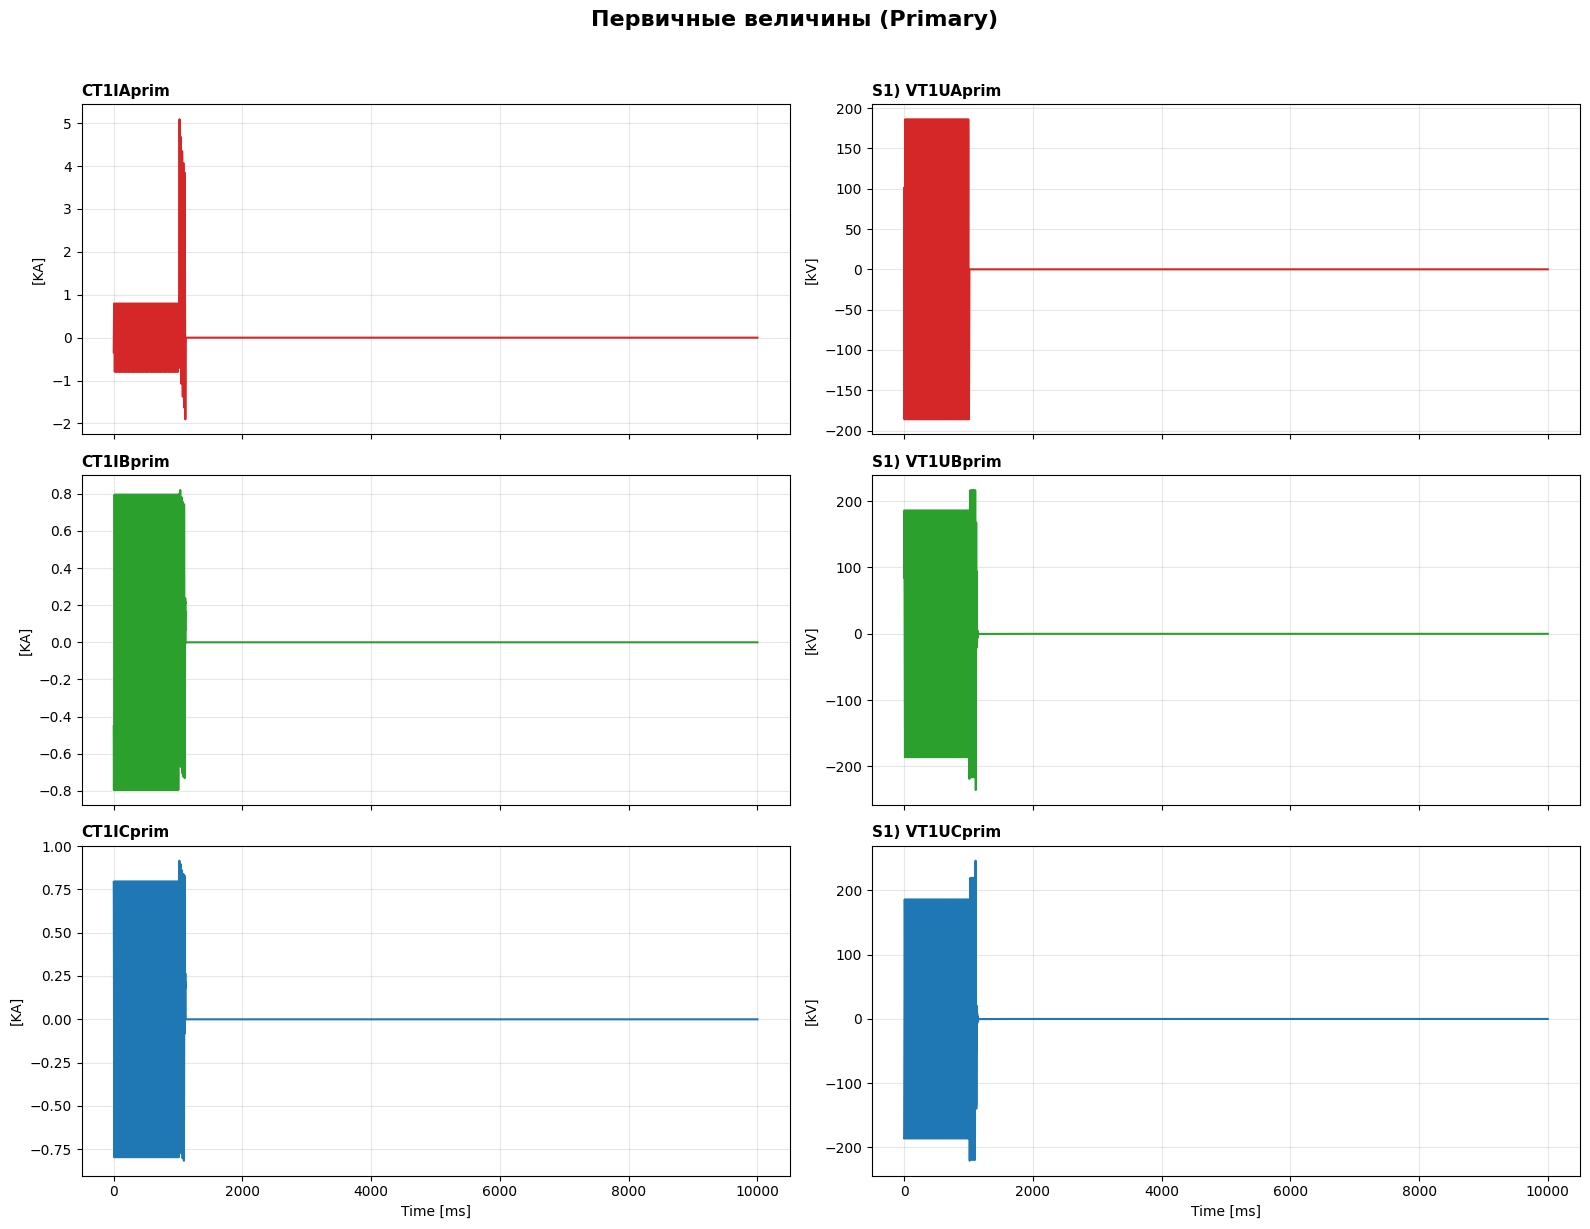

In [20]:
def plot_phases(rec, i_data, u_data, i_nums, u_nums, title="Осциллограммы"):
    """
    Визуализация фаз A, B, C с названиями каналов и единицами измерения из CFG.
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    
    time_ms = np.array(rec.time) * 1000
    colors = ['#d62728', '#2ca02c', '#1f77b4'] # A, B, C
    
    # Вспомогательная функция для получения метаданных (название и единица)
    def get_meta(nums, idx_in_list):
        try:
            ch_idx = nums[idx_in_list] - 1
            channel = rec.cfg.analog_channels[ch_idx]
            return channel.name, channel.uu
        except:
            return f"Channel {idx_in_list}", "?"

    for row in range(3):
        # --- ТОКИ (Левая колонка) ---
        name_i, unit_i = get_meta(i_nums, row)
        ax_i = axes[row, 0]
        ax_i.plot(time_ms, i_data[row], color=colors[row], lw=1.5)
        ax_i.set_ylabel(f"[{unit_i}]")
        ax_i.set_title(f"{name_i}", loc='left', fontweight='bold', fontsize=11)
        ax_i.grid(True, alpha=0.3)
        
        # --- НАПРЯЖЕНИЯ (Правая колонка) ---
        name_u, unit_u = get_meta(u_nums, row)
        ax_u = axes[row, 1]
        ax_u.plot(time_ms, u_data[row], color=colors[row], lw=1.5)
        ax_u.set_ylabel(f"[{unit_u}]")
        ax_u.set_title(f"{name_u}", loc='left', fontweight='bold', fontsize=11)
        ax_u.grid(True, alpha=0.3)

    # Общие подписи осей X
    axes[2, 0].set_xlabel("Time [ms]")
    axes[2, 1].set_xlabel("Time [ms]")
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Использование (убедись, что i_p_idx и u_p_idx определены в ячейке выше)
plot_phases(rec, I_prim, U_prim, i_p_idx, u_p_idx, title="Первичные величины (Primary)")


## Раздел 2: Фильтрация Баттерворта (удаление DC)

In [ ]:
from scipy import signal
import pandas as pd

ORDER = 4
FC = 25.0

def butterworth_highpass(data, fs, fc, order=4):
    """
    Фильтр Баттерворта высоких частот (ФВЧ).
    Удаляет постоянное смещение нуля (DC offset) и медленно меняющуюся апериодику.
    Для полного подавления апериодической составляющей КЗ рекомендуется fc < 5 Гц.
    """
    nyq = 0.5 * fs
    wn = fc / nyq
    sos = signal.butter(order, wn, btype='highpass', output='sos')
    filtered = signal.sosfiltfilt(sos, data, axis=1)
    return filtered, sos

def remove_dc_period(data, fs, f_net):
    """
    Удаление апериодической составляющей методом центрированного
    скользящего среднего за период сетевой частоты (20 мс для 50 Гц).
    Этот метод не вносит фазовых искажений и минимизирует краевые артефакты.
    """
    period = int(fs / f_net)
    filtered = np.zeros_like(data)
    for i in range(data.shape[0]):
        s = pd.Series(data[i])
        aper = s.rolling(window=period, center=True, min_periods=1).mean()
        half = period // 2
        aper.iloc[:half] = aper.iloc[half:period].mean()
        aper.iloc[-half:] = aper.iloc[-period:-half].mean()
        filtered[i] = data[i] - aper.values
    return filtered

try:
    FS = rec.cfg.sample_rates[0][0]
    print(f"Частота дискретизации: {FS}")
except (AttributeError, IndexError):
    print("X Частота дискретизации не найдена")

# Центрирование по предыстории (первые 20 мс) перед фильтрацией —
# стандартная практика для устранения смещения нуля ТТ/ТН
pre_window = int(0.02 * FS)
for i in range(3):
    I_prim[i] -= np.mean(I_prim[i, :pre_window])
    U_prim[i] -= np.mean(U_prim[i, :pre_window])

# === Выбор метода фильтрации ===
# Рекомендуется: remove_dc_period (нет краевых артефактов)
# Альтернатива: butterworth_highpass (FC=25 Гц — только DC offset)
I_prim_filt = remove_dc_period(I_prim, FS, rec.cfg.frequency)
U_prim_filt = remove_dc_period(U_prim, FS, rec.cfg.frequency)
sos_I = sos_U = None  # SOS не используются для метода скользящего среднего

# Обновляем filtered-переменные для следующих разделов
IA_filtered = I_prim_filt[0]
IB_filtered = I_prim_filt[1]
IC_filtered = I_prim_filt[2]
UA_filtered = U_prim_filt[0]
UB_filtered = U_prim_filt[1]
UC_filtered = U_prim_filt[2]

print("✓ Фильтрация выполнена (метод скользящего среднего за период).")


## Визауализация Баттерворта

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
t_ms = np.array(rec.time) * 1000

# 1. Ток фазы А: до и после фильтрации
axes[0, 0].plot(t_ms, I_prim[0], 'gray', alpha=0.5, label='Исходный')
axes[0, 0].plot(t_ms, I_prim_filt[0], 'r-', label='Отфильтрованный')
axes[0, 0].set_ylabel('IA, кА')
axes[0, 0].set_title('Ток фазы А: до и после фильтрации')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. DC-составляющая (скользящее среднее за период 20 мс)
window_size = int(0.02 * FS)
dc_before = np.convolve(I_prim[0], np.ones(window_size)/window_size, mode='same')
dc_after = np.convolve(I_prim_filt[0], np.ones(window_size)/window_size, mode='same')

axes[1, 0].plot(t_ms, dc_before, 'gray', alpha=0.7, label='DC до')
axes[1, 0].plot(t_ms, dc_after, 'b-', label='DC после')
axes[1, 0].set_ylabel('Среднее, кА')
axes[1, 0].set_title('DC составляющая (IA)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 3. АЧХ фильтра Баттерворта (для справки)
sos_ref = signal.butter(ORDER, FC/(0.5*FS), btype='highpass', output='sos')
w, h = signal.sosfreqz(sos_ref, worN=2000, fs=FS)
axes[0, 1].semilogx(w, 20*np.log10(np.abs(h) + 1e-10), 'b-', linewidth=2)
axes[0, 1].axvline(x=FC, color='red', linestyle='--', label=f'fc = {FC} Гц')
axes[0, 1].axvline(x=50, color='green', linestyle='--', label='50 Гц')
axes[0, 1].set_ylabel('Амплитуда, дБ')
axes[0, 1].set_title('АЧХ эталонного ФВЧ Баттерворта')
axes[0, 1].legend()
axes[0, 1].grid(True, which='both')
axes[0, 1].set_ylim([-60, 5])

# 4. ВСЕ ТОКИ после фильтрации
axes[1, 1].plot(t_ms, I_prim_filt[0], 'r-', label='IA', lw=1)
axes[1, 1].plot(t_ms, I_prim_filt[1], 'g-', label='IB', lw=1)
axes[1, 1].plot(t_ms, I_prim_filt[2], 'b-', label='IC', lw=1)
axes[1, 1].set_ylabel('Ток, кА')
axes[1, 1].set_xlabel('Время, мс')
axes[1, 1].set_title('Все фазы после фильтрации')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


## Сохранение отфильтрованных токов и напряжений обратно в Comtrade

In [ ]:
import numpy as np
from datetime import datetime

file_name = "filtered_data"

# 1. Формируем заголовок CFG строго по IEEE C37.111-1999
station_name = "FILTERED"
rec_dev_id = "PY_SCRIPT"
rev_year = "1999"
nA = 6
nD = 0
tt = nA + nD

cfg_lines = [
    f"{station_name},{rec_dev_id},{rev_year}",
    f"{tt},{nA}A,{nD}D",
]

all_signals = [
    np.array(I_prim_filt[0]), np.array(I_prim_filt[1]), np.array(I_prim_filt[2]),
    np.array(U_prim_filt[0]), np.array(U_prim_filt[1]), np.array(U_prim_filt[2])
]
names = ["IA_filt", "IB_filt", "IC_filt", "UA_filt", "UB_filt", "UC_filt"]
phases = ["A", "B", "C", "A", "B", "C"]
units = ["kA", "kA", "kA", "kV", "kV", "kV"]

for i in range(6):
    sig = all_signals[i]
    ch_id = names[i]
    ph = phases[i]
    ccbm = ""
    uu = units[i]
    a = 1.0
    b = 0.0
    skew = 0
    min_val = int(np.floor(np.min(sig)))
    max_val = int(np.ceil(np.max(sig)))
    primary = 1
    secondary = 1
    ps = "P"
    cfg_lines.append(f"{i+1},{ch_id},{ph},{ccbm},{uu},{a},{b},{skew},{min_val},{max_val},{primary},{secondary},{ps}")

lf = int(rec.cfg.frequency)
nrates = 1
npts = len(all_signals[0])
start_dt = datetime.now().strftime("%d/%m/%Y,%H:%M:%S.%f")[:-3]
trigger_dt = start_dt

cfg_lines.extend([
    str(lf),
    str(nrates),
    f"{int(FS)},{npts}",
    start_dt,
    trigger_dt,
    "ASCII",
    "1"
])

with open(f"{file_name}.cfg", "w", newline="") as f:
    f.write("\n".join(cfg_lines) + "\n")

# 2. Формируем DAT (ASCII)
dt_us = int(1_000_000 / FS)
with open(f"{file_name}.dat", "w", newline="") as f:
    for i in range(npts):
        t_us = i * dt_us
        vals = ",".join([f"{sig[i]:.6f}" for sig in all_signals])
        f.write(f"{i+1},{t_us},{vals}\n")

print(f"✅ Созданы файлы: {file_name}.cfg и {file_name}.dat (IEEE C37.111-1999)")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

def analyze_signals_full(data_dict, fs=5000, fault_idx=None, threshold=5.0):
    """
    Анализ апериодической составляющей.
    Оценка DC% производится на предыстории (до момента КЗ),
    где фильтрация должна обеспечивать полное подавление DC.
    """
    window_size = int(fs * 0.02)  # окно в 20 мс
    half_w = window_size // 2
    results = {}
    
    names = list(data_dict.keys())
    fig, axes = plt.subplots(len(names), 1, figsize=(12, 4 * len(names)))
    if len(names) == 1:
        axes = [axes]

    print(f"{'Канал':<12} | {'DC %':<10} | {'Ta (мс)':<10} | {'Статус'}")
    print("-" * 50)

    for i, name in enumerate(names):
        signal_full = np.array(data_dict[name]).flatten()
        
        # Для оценки DC используем предысторию (до КЗ) или весь сигнал
        if fault_idx is not None and fault_idx > window_size:
            eval_sig = signal_full[:fault_idx]
        else:
            eval_sig = signal_full
        
        if len(eval_sig) > window_size:
            aper_eval = uniform_filter1d(eval_sig, size=window_size, mode='nearest')
            sig_eval = eval_sig[half_w:-half_w]
            aper_eval = aper_eval[half_w:-half_w]
        else:
            aper_eval = uniform_filter1d(eval_sig, size=len(eval_sig), mode='nearest')
            sig_eval = eval_sig
        
        ac_eval = sig_eval - aper_eval
        peak_ac = np.max(np.abs(ac_eval))
        max_dc = np.max(np.abs(aper_eval))
        ratio = (max_dc / peak_ac * 100) if peak_ac > 0 else 0
        
        abs_dc = np.abs(aper_eval)
        idx_peak = np.argmax(abs_dc)
        val_peak = abs_dc[idx_peak]
        target = val_peak * 0.368
        ta = 0
        fragment = abs_dc[idx_peak:]
        for j, val in enumerate(fragment):
            if val <= target:
                ta = (j / fs) * 1000
                break
        
        results[name] = {"ratio": ratio, "ta": ta}
        status = "⚠️ ВЫСОКАЯ" if ratio > threshold else "✅ НОРМА"
        ta_display = f"{ta:.1f}" if ta > 0 else "> окна"
        print(f"{name:<12} | {ratio:>7.2f}% | {ta_display:>9} | {status}")

        ax = axes[i]
        t_full = np.arange(len(signal_full)) / fs * 1000
        aper_full = uniform_filter1d(signal_full, size=window_size, mode='nearest')
        ax.plot(t_full, signal_full, color='gray', alpha=0.4, label='Исходный сигнал')
        ax.plot(t_full, aper_full, color='red', linewidth=2, label='DC (апериодика)')
        ax.plot(t_full, signal_full - aper_full, color='blue', alpha=0.7, label='AC (основная)')
        if fault_idx is not None:
            ax.axvline(x=fault_idx/fs*1000, color='magenta', linestyle='--', alpha=0.5, label='КЗ')
        ax.axvspan(0, half_w/fs*1000, color='yellow', alpha=0.1)
        ax.axvspan(t_full[-1] - half_w/fs*1000, t_full[-1], color='yellow', alpha=0.1)
        ax.set_title(f"Анализ канала: {name} (DC={ratio:.1f}%, Ta={ta_display} мс)")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return results

data_to_test = {
    "IA_filt": np.array(I_prim_filt[0]).flatten(),
    "IB_filt": np.array(I_prim_filt[1]).flatten(),
    "IC_filt": np.array(I_prim_filt[2]).flatten(),
    "UA_filt": np.array(U_prim_filt[0]).flatten(),
    "UB_filt": np.array(U_prim_filt[1]).flatten(),
    "UC_filt": np.array(U_prim_filt[2]).flatten()
}


## Раздел 3: Детекция момента КЗ

In [ ]:
def detect_fault_inception(ia, ib, ic, fs, f_net, Inom, eta=0.2):
    """Детекция момента КЗ по производной тока (дифференциальный метод)."""
    k = int(fs / (4 * f_net))
    
    delta_Ia = np.abs(ia[k:] - ia[:-k])
    delta_Ib = np.abs(ib[k:] - ib[:-k])
    delta_Ic = np.abs(ic[k:] - ic[:-k])
    delta_I = np.maximum(np.maximum(delta_Ia, delta_Ib), delta_Ic)
    delta_I = np.concatenate([np.zeros(k), delta_I])
    
    threshold = eta * Inom
    candidates = np.where(delta_I > threshold)[0]
    
    if len(candidates) == 0:
        return None, delta_I
    
    fault_idx = candidates[0]
    search_window = int(0.02 * fs)
    start = max(0, fault_idx - search_window)
    end = min(len(delta_I), fault_idx + search_window)
    fault_idx = start + np.argmax(delta_I[start:end])
    
    return fault_idx, delta_I

ETA = 0.15
fault_idx_detected, delta_I = detect_fault_inception(
    IA_filtered, IB_filtered, IC_filtered,
    data['fs'], data['frequency'], data['Inom'], ETA
)

fault_time_detected = fault_idx_detected / data['fs'] if fault_idx_detected is not None else None

print("✓ Детекция КЗ выполнена")
print(f"  Порог: {ETA * 100:.0f}% от Inom = {ETA * data['Inom']:.3f} кА")
if fault_time_detected is not None:
    print(f"  Обнаружено: отсчёт {fault_idx_detected}, время {fault_time_detected*1000:.2f} мс")
    if data['fault_time'] is not None:
        print(f"  Истинное время: {data['fault_time']*1000:.2f} мс")
        print(f"  Ошибка: {abs(fault_time_detected - data['fault_time'])*1000:.2f} мс")
else:
    print("  ⚠️ КЗ не обнаружено")

# Анализ качества фильтрации на предыстории
results = analyze_signals_full(data_to_test, fs=data['fs'], fault_idx=fault_idx_detected)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
t_ms = np.arange(len(IA_filtered)) / data['fs'] * 1000
threshold = ETA * data['Inom']

axes[0].plot(t_ms, IA_filtered, 'r-', label='IA')
axes[0].plot(t_ms, IB_filtered, 'g-', label='IB')
axes[0].plot(t_ms, IC_filtered, 'b-', label='IC')
if data['fault_time'] is not None:
    axes[0].axvline(x=data['fault_time']*1000, color='cyan', linestyle='-', linewidth=2, label='Истинное КЗ')
if fault_time_detected is not None:
    axes[0].axvline(x=fault_time_detected*1000, color='magenta', linestyle='--', linewidth=2, label='Обнаружено')
axes[0].set_ylabel('Ток, кА')
axes[0].set_title('Детекция момента КЗ')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_ms, delta_I, 'k-', label='ΔI')
axes[1].axhline(y=threshold, color='red', linestyle='--', label='Порог')
if data['fault_time'] is not None:
    axes[1].axvline(x=data['fault_time']*1000, color='cyan', linestyle='-', linewidth=2)
if fault_time_detected is not None:
    axes[1].axvline(x=fault_time_detected*1000, color='magenta', linestyle='--', linewidth=2)
    axes[1].scatter([fault_time_detected*1000], [delta_I[fault_idx_detected]], color='magenta', s=100)
axes[1].set_ylabel('ΔI, кА')
axes[1].set_xlabel('Время, мс')
axes[1].set_title('Изменение тока')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

if fault_idx_detected is not None:
    print(f"Максимальное ΔI: {np.max(delta_I):.3f} кА")
    print(f"Отношение к номиналу: {np.max(delta_I)/data['Inom']:.2f}")


## Раздел 4: Оконирование сигнала

In [ ]:
T_PRE = 0.050
T_POST = 0.150

N_PRE = int(T_PRE * data['fs'])
N_POST = int(T_POST * data['fs'])
L_WINDOW = N_PRE + N_POST

if fault_idx_detected is None:
    # Если КЗ не обнаружено — берём центр записи как запасной вариант
    fault_idx_detected = len(IA_filtered) // 2
    print("⚠️ КЗ не обнаружено, окно центрировано относительно середины записи")

def extract_window(signal, center, n_pre, n_post):
    """Извлекает окно фиксированной длины n_pre + n_post с дополнением нулями при выходе за границы."""
    start = center - n_pre
    end = center + n_post
    pad_left = max(0, -start)
    pad_right = max(0, end - len(signal))
    valid_start = max(0, start)
    valid_end = min(len(signal), end)
    window = np.concatenate([
        np.zeros(pad_left),
        signal[valid_start:valid_end],
        np.zeros(pad_right)
    ])
    return window

IA_window = extract_window(IA_filtered, fault_idx_detected, N_PRE, N_POST)
IB_window = extract_window(IB_filtered, fault_idx_detected, N_PRE, N_POST)
IC_window = extract_window(IC_filtered, fault_idx_detected, N_PRE, N_POST)
UA_window = extract_window(UA_filtered, fault_idx_detected, N_PRE, N_POST)
UB_window = extract_window(UB_filtered, fault_idx_detected, N_PRE, N_POST)
UC_window = extract_window(UC_filtered, fault_idx_detected, N_PRE, N_POST)

t_window = np.arange(-N_PRE, N_POST) / data['fs'] * 1000

print("✓ Оконирование выполнено")
print(f"  Предыстория: {T_PRE*1000:.0f} мс = {N_PRE} отсчётов")
print(f"  Постистория: {T_POST*1000:.0f} мс = {N_POST} отсчётов")
print(f"  Общая длина: {L_WINDOW} отсчётов")


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(t_window, IA_window, 'r-', label='IA')
axes[0].plot(t_window, IB_window, 'g-', label='IB')
axes[0].plot(t_window, IC_window, 'b-', label='IC')
axes[0].axvline(x=0, color='magenta', linestyle='--', linewidth=2, label='КЗ')
axes[0].axvspan(-T_PRE*1000, 0, alpha=0.1, color='green', label='Предыстория')
axes[0].axvspan(0, T_POST*1000, alpha=0.1, color='red', label='Постистория')
axes[0].set_ylabel('Ток, кА')
axes[0].set_title('Токи в окне анализа')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_window, UA_window, 'r-', label='UA')
axes[1].plot(t_window, UB_window, 'g-', label='UB')
axes[1].plot(t_window, UC_window, 'b-', label='UC')
axes[1].axvline(x=0, color='magenta', linestyle='--', linewidth=2)
axes[1].axvspan(-T_PRE*1000, 0, alpha=0.1, color='green')
axes[1].axvspan(0, T_POST*1000, alpha=0.1, color='red')
axes[1].set_ylabel('Напряжение, кВ')
axes[1].set_xlabel('Время от момента КЗ, мс')
axes[1].set_title('Напряжения в окне анализа')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Амплитуда IA до КЗ: {np.max(np.abs(IA_window[:N_PRE])):.2f} кА")
print(f"Амплитуда IA после КЗ: {np.max(np.abs(IA_window[N_PRE:])):.2f} кА")


## Раздел 5: Симметричные составляющие (Фортескю)

In [ ]:
def fortescue_instantaneous(ia, ib, ic, fs, f_net):
    """Вычисление мгновенных симметричных составляющих по Фортескю."""
    L = len(ia)
    i0 = np.zeros(L)
    i1 = np.zeros(L)
    i2 = np.zeros(L)
    
    k = int(fs / (3 * f_net))
    
    for n in range(L):
        i0[n] = (ia[n] + ib[n] + ic[n]) / 3
        
        idx_b1 = n - k
        idx_c1 = n - 2*k
        if idx_b1 >= 0 and idx_c1 >= 0:
            i1[n] = (ia[n] + ib[idx_b1] + ic[idx_c1]) / 3
        else:
            i1[n] = i0[n]
        
        idx_b2 = n - 2*k
        idx_c2 = n - k
        if idx_b2 >= 0 and idx_c2 >= 0:
            i2[n] = (ia[n] + ib[idx_b2] + ic[idx_c2]) / 3
        else:
            i2[n] = 0
    
    return i0, i1, i2

I0, I1, I2 = fortescue_instantaneous(IA_window, IB_window, IC_window, data['fs'], data['frequency'])
U0, U1, U2 = fortescue_instantaneous(UA_window, UB_window, UC_window, data['fs'], data['frequency'])

print("✓ Симметричные составляющие вычислены")
print(f"  Сдвиг k = {int(data['fs']/(3*data['frequency']))} отсчётов = 120°")


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(t_window, I0, 'purple', label='I₀')
axes[0, 0].plot(t_window, I1, 'blue', label='I₁')
axes[0, 0].plot(t_window, I2, 'orange', label='I₂')
axes[0, 0].axvline(x=0, color='magenta', linestyle='--')
axes[0, 0].set_ylabel('Ток, кА')
axes[0, 0].set_title('Симметричные составляющие тока')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t_window, U0, 'purple', label='U₀')
axes[0, 1].plot(t_window, U1, 'blue', label='U₁')
axes[0, 1].plot(t_window, U2, 'orange', label='U₂')
axes[0, 1].axvline(x=0, color='magenta', linestyle='--')
axes[0, 1].set_ylabel('Напряжение, кВ')
axes[0, 1].set_title('Симметричные составляющие напряжения')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(t_window, IA_window, 'r-', alpha=0.5, label='IA')
axes[1, 0].plot(t_window, IB_window, 'g-', alpha=0.5, label='IB')
axes[1, 0].plot(t_window, IC_window, 'b-', alpha=0.5, label='IC')
axes[1, 0].plot(t_window, I1, 'k-', linewidth=2, label='I₁')
axes[1, 0].axvline(x=0, color='magenta', linestyle='--')
axes[1, 0].set_ylabel('Ток, кА')
axes[1, 0].set_title('Фазные токи vs I₁')
axes[1, 0].legend()
axes[1, 0].grid(True)

sum_abc = (IA_window + IB_window + IC_window) / 3
axes[1, 1].plot(t_window, sum_abc, 'gray', alpha=0.7, label='(IA+IB+IC)/3')
axes[1, 1].plot(t_window, I0, 'purple', linewidth=2, label='I₀')
axes[1, 1].axvline(x=0, color='magenta', linestyle='--')
axes[1, 1].set_ylabel('Ток, кА')
axes[1, 1].set_title('Проверка: I₀ = среднее')
axes[1, 1].legend()
axes[1, 1].grid(True)

post_fault_idx = N_PRE
I1_rms = np.sqrt(np.mean(I1[post_fault_idx:]**2))
I2_rms = np.sqrt(np.mean(I2[post_fault_idx:]**2))
I0_rms = np.sqrt(np.mean(I0[post_fault_idx:]**2))

ratio_21 = I2_rms / (I1_rms + 1e-10)
ratio_01 = I0_rms / (I1_rms + 1e-10)

axes[2, 0].bar(['I₂/I₁', 'I₀/I₁'], [ratio_21, ratio_01], color=['orange', 'purple'])
axes[2, 0].axhline(y=1.0, color='red', linestyle='--')
axes[2, 0].set_ylabel('Отношение')
axes[2, 0].set_title('Отношения (признаки типа КЗ)')
axes[2, 0].grid(True, axis='y')

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nI₁ (действ.): {I1_rms:.3f} кА")
print(f"I₂ (действ.): {I2_rms:.3f} кА")
print(f"I₀ (действ.): {I0_rms:.3f} кА")
print(f"I₂/I₁ = {ratio_21:.3f}")
print(f"I₀/I₁ = {ratio_01:.3f}")


## Раздел 6: Классификация вида КЗ

In [ ]:
def classify_fault_type(I1_rms, I2_rms, I0_rms):
    """Классификация вида КЗ"""
    ratio_21 = I2_rms / (I1_rms + 1e-10)
    ratio_01 = I0_rms / (I1_rms + 1e-10)
    
    if ratio_21 < 0.15 and ratio_01 < 0.15:
        fault_type = '3ф'
        one_hot = np.array([1, 0, 0, 0])
    elif ratio_21 > 0.7 and ratio_01 < 0.25:
        fault_type = '2ф'
        one_hot = np.array([0, 1, 0, 0])
    elif ratio_21 > 0.7 and ratio_01 > 0.7:
        fault_type = '1ф-З'
        one_hot = np.array([0, 0, 0, 1])
    elif 0.25 < ratio_21 < 0.7 and 0.25 < ratio_01 < 0.7:
        fault_type = '2ф-З'
        one_hot = np.array([0, 0, 1, 0])
    else:
        fault_type = 'неопределено'
        one_hot = np.array([0.25, 0.25, 0.25, 0.25])
    
    return fault_type, one_hot, (ratio_21, ratio_01)

fault_type, one_hot, ratios = classify_fault_type(I1_rms, I2_rms, I0_rms)
ratio_21, ratio_01 = ratios

print(f"✓ Классификация: {fault_type}")

In [ ]:
# Визуализация классификации
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_xlim([0, 1.5])
axes[0].set_ylim([0, 1.5])

from matplotlib.patches import Rectangle
axes[0].add_patch(Rectangle((0, 0), 0.15, 0.15, facecolor='green', alpha=0.3))
axes[0].add_patch(Rectangle((0.7, 0), 0.8, 0.25, facecolor='blue', alpha=0.3))
axes[0].add_patch(Rectangle((0.7, 0.7), 0.8, 0.8, facecolor='red', alpha=0.3))
axes[0].add_patch(Rectangle((0.25, 0.25), 0.45, 0.45, facecolor='orange', alpha=0.3))

axes[0].scatter([ratio_21], [ratio_01], s=300, c='magenta', marker='*', edgecolors='black', linewidths=2)
axes[0].set_xlabel('I₂/I₁')
axes[0].set_ylabel('I₀/I₁')
axes[0].set_title('Решающие области')
axes[0].grid(True)

labels = ['3ф', '2ф', '2ф-З', '1ф-З']
colors = ['green', 'blue', 'orange', 'red']
bars = axes[1].bar(labels, one_hot, color=colors, edgecolor='black', linewidth=2)

for bar, val in zip(bars, one_hot):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{val:.2f}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_ylabel('Вероятность')
axes[1].set_title(f'Результат: {fault_type}')
axes[1].set_ylim([0, 1.2])
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"One-hot: {one_hot}")

## Раздел 7: Нормализация в per-unit (p.u.)

In [ ]:
# =============================================================================
# Нормализация в per-unit (p.u.)
# =============================================================================
# Задайте нужные значения вручную:
S_BASE_MVA = 100.0          # Базовая мощность, МВА
FAULT_DISTANCE_KM = 10.0    # Расстояние до КЗ, км (задайте вручную)

LINE_PARAMS = {
    'Unom_kv': 110.0,
    'L_km': 50.0,
    'r1_ohm_km': 0.1,
    'x1_ohm_km': 0.4,
}

U_base_kV = LINE_PARAMS['Unom_kv'] / np.sqrt(3)
I_base_kA = S_BASE_MVA / (np.sqrt(3) * LINE_PARAMS['Unom_kv'])

print("=== БАЗОВЫЕ ВЕЛИЧИНЫ ===")
print(f"U_base = {U_base_kV:.2f} кВ (фазное)")
print(f"I_base = {I_base_kA:.3f} кА")
print(f"Z₁ = {np.sqrt((LINE_PARAMS['r1_ohm_km']*LINE_PARAMS['L_km'])**2 + (LINE_PARAMS['x1_ohm_km']*LINE_PARAMS['L_km'])**2):.2f} Ом")

I0_pu = I0 / I_base_kA
I1_pu = I1 / I_base_kA
I2_pu = I2 / I_base_kA
U0_pu = U0 / U_base_kV
U1_pu = U1 / U_base_kV
U2_pu = U2 / U_base_kV

if FAULT_DISTANCE_KM is not None and LINE_PARAMS['L_km'] > 0:
    d_target_pu = FAULT_DISTANCE_KM / LINE_PARAMS['L_km']
    print(f"\nЦель: {FAULT_DISTANCE_KM:.1f} км = {d_target_pu:.3f} p.u.")
else:
    d_target_pu = None
    print("\nЦель: не задана (FAULT_DISTANCE_KM = None)")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(t_window, I1_pu, 'b-', label='I₁')
axes[0, 0].plot(t_window, I2_pu, 'orange', label='I₂')
axes[0, 0].plot(t_window, I0_pu, 'purple', label='I₀')
axes[0, 0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='magenta', linestyle='--')
axes[0, 0].set_ylabel('Ток, p.u.')
axes[0, 0].set_title('Токи в p.u.')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t_window, U1_pu, 'b-', label='U₁')
axes[0, 1].plot(t_window, U2_pu, 'orange', label='U₂')
axes[0, 1].plot(t_window, U0_pu, 'purple', label='U₀')
axes[0, 1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='magenta', linestyle='--')
axes[0, 1].set_ylabel('Напряжение, p.u.')
axes[0, 1].set_title('Напряжения в p.u.')
axes[0, 1].legend()
axes[0, 1].grid(True)

categories = ['I₁', 'I₂', 'I₀', 'U₁', 'U₂', 'U₀']
after = [np.max(np.abs(I1_pu)), np.max(np.abs(I2_pu)), np.max(np.abs(I0_pu)),
         np.max(np.abs(U1_pu)), np.max(np.abs(U2_pu)), np.max(np.abs(U0_pu))]

x = np.arange(len(categories))
axes[1, 0].bar(x, after, color=['blue', 'orange', 'purple', 'blue', 'orange', 'purple'])
axes[1, 0].set_ylabel('Амплитуда, p.u.')
axes[1, 0].set_title('Максимальные значения в p.u.')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(categories)
axes[1, 0].grid(True, axis='y')

if d_target_pu is not None:
    axes[1, 1].barh(['Расстояние'], [d_target_pu], color='green', edgecolor='black', height=0.3)
    axes[1, 1].set_xlim([0, 1])
    axes[1, 1].set_xlabel('p.u.')
    axes[1, 1].set_title(f'Цель: {d_target_pu:.3f} p.u.')
    axes[1, 1].text(d_target_pu/2, 0, f'{FAULT_DISTANCE_KM:.1f} км', 
                    ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    axes[1, 1].set_yticks([])
else:
    axes[1, 1].text(0.5, 0.5, 'Цель не задана', ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=14)
    axes[1, 1].set_title('Цель: не задана')

plt.tight_layout()
plt.show()

print(f"Макс I₁ после КЗ: {np.max(np.abs(I1_pu[N_PRE:])):.2f} p.u.")
print(f"Мин U₁ после КЗ: {np.min(np.abs(U1_pu[N_PRE:])):.2f} p.u.")


## Раздел 8: Формирование итогового тензора

In [ ]:
one_hot_3f = np.full(L_WINDOW, one_hot[0])
one_hot_2f = np.full(L_WINDOW, one_hot[1])
one_hot_2fg = np.full(L_WINDOW, one_hot[2])
one_hot_1fg = np.full(L_WINDOW, one_hot[3])

X = np.array([
    I1_pu, I2_pu, I0_pu,
    U1_pu, U2_pu, U0_pu,
    one_hot_3f, one_hot_2f, one_hot_2fg, one_hot_1fg
])

y = d_target_pu if d_target_pu is not None else np.nan

print("✓ Итоговый тензор сформирован")
print(f"  Форма X: {X.shape} (каналы × время)")
if d_target_pu is not None:
    print(f"  Целевая переменная y: {y:.4f} p.u.")
else:
    print("  Целевая переменная y: не задана (задайте FAULT_DISTANCE_KM)")


In [ ]:
# Визуализация итогового тензора
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

channel_names = [
    'I₁ (прямая ток)', 'I₂ (обратная ток)', 'I₀ (нулевая ток)',
    'U₁ (прямая напр.)', 'U₂ (обратная напр.)', 'U₀ (нулевая напр.)',
    'one-hot: 3ф', 'one-hot: 2ф', 'one-hot: 2ф-З', 'one-hot: 1ф-З'
]

colors = ['blue', 'orange', 'purple', 'blue', 'orange', 'purple', 
          'green', 'blue', 'orange', 'red']

for i in range(10):
    axes[i].plot(t_window, X[i], color=colors[i], linewidth=1.5)
    axes[i].axvline(x=0, color='magenta', linestyle='--', alpha=0.7)
    axes[i].set_ylabel(f'Канал {i}')
    axes[i].set_title(channel_names[i])
    axes[i].grid(True)
    
    if i >= 6:
        axes[i].text(0.02, 0.5, f'{X[i, 0]:.2f}', 
                    transform=axes[i].transAxes, fontsize=14,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

fig.suptitle(f'Итоговый тензор X ∈ R^(10×{L_WINDOW})\\nЦель: {y:.3f} p.u.', 
             fontsize=14, fontweight='bold')

for i in [8, 9]:
    axes[i].set_xlabel('Время от момента КЗ, мс')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print(f"\n{'Канал':<8} {'Название':<25} {'Диапазон':<20}")
print("-" * 55)
for i, name in enumerate(channel_names):
    min_val, max_val = np.min(X[i]), np.max(X[i])
    print(f"{i:<8} {name:<25} [{min_val:6.2f}, {max_val:6.2f}]")

print(f"\nЦелевая переменная: y = {y:.4f} p.u. = {y*100:.1f}% от длины линии")

In [ ]:
output_data = {
    'X': X,
    'y': y,
    'metadata': {
        'fault_type': fault_type,
        'fault_distance_km': FAULT_DISTANCE_KM,
        'line_length_km': LINE_PARAMS['L_km'],
        'sample_rate': data['fs'],
        'window_samples': L_WINDOW,
        'channel_names': channel_names
    }
}

np.savez('fault_sample_processed.npz', **output_data)
print("✓ Сохранено в 'fault_sample_processed.npz'")
